In [208]:
import os
import importlib
import numpy as np, pandas as pd, networkx as nx
import desikan_killiany_atlas as dkatlas
import utils_a3 as utils
import watts_in_adni as nwm

import utils_a1_a3 as utils_a1
import gudhi_persistence_a3 as gp_a1

import matplotlib.pyplot as plt
import lifelines
from sklearn.decomposition import PCA

PATH = os.getcwd()
BASE_DIR = utils.BASE_DIR
print(f"utils base directory: {BASE_DIR}")

utils base directory: C:\Users\sranasin\PycharmProjects\NetworkModels


In [209]:
# reload all
importlib.reload(utils); importlib.reload(nwm); importlib.reload(gp_a1)
importlib.reload(utils_a1); importlib.reload(dkatlas)

<module 'desikan_killiany_atlas' from 'C:\\Users\\sranasin\\PycharmProjects\\NetworkModels\\Project1\\A3\\desikan_killiany_atlas.py'>

In [210]:
params = {'ngeom_edges_in_persistence': True, 'max_persistence_dim': 2,
               'calculate_representation': True, 'bandwidth': 0.1,
               'resolution': 50, 'num_landscapes': 3,
               'representation_choice_function': 'persistence',
                'non_active': -1
               }
params['query_filter'] = "rid in [21, 31]"
adni_data_rel_path = os.path.join("resources", "adni_pet_image_analysis", "TAU", "ADNI_merged_diagnosis.csv")
graph_file_rel_path = os.path.join("resources", "base_data", "DKATLAS33_base.graphml")

In [9]:
df_adni = utils.df_rename_to_fsnames(adni_data_rel_path, type_filter="tau")
df_adni = utils.safe_filter_df(df_adni, True, type_filter="tau")
df_adni.sort_values(by = ['rid', 'scandate'], inplace = True)
df_adni = df_adni.query(params.get('query_filter'))
df_adni, feature_cols = utils.activations_cortical_regions_df(df_adni, True)
print(f"Shape of df_adni processed: {df_adni.shape}")
df_adni.head(10)

Shape of df_adni processed: (3, 177)


,loniuid,ptid,rid,scandate,qc_flag,tracer,rh_lateralorbitofrontal,rh_parsorbitalis,rh_frontalpole,rh_medialorbitofrontal,...,lh_transversetemporal_positivity,lh_insula_positivity,lh_thalamus_proper_positivity,lh_caudate_positivity,lh_putamen_positivity,lh_pallidum_positivity,lh_accumbens_area_positivity,lh_hippocampus_positivity,lh_amygdala_positivity,brainstem_positivity
0,1594604,011_S_0021,21,02/02/2018,2,FTP,1.238,1.293,1.148,1.134,...,0,0,1,1,1,1,0,1,0,0
2,1596172,023_S_0031,31,04/23/2019,2,FTP,1.138,1.154,1.139,1.088,...,0,0,0,0,1,1,0,1,1,0
1,1596177,023_S_0031,31,04/24/2018,2,FTP,1.198,1.160,1.073,1.151,...,0,0,0,0,1,1,0,1,0,0


### COX

In [ ]:
### RID's that only changed status # 4400, 2304 -- QC Flag error [ --> change utils_a3.activation_times_of_patients_for_cortical_regions_df.state_value_col = any('summary_diagnosis_MCI', 'summary_diagnosis_AD'])
params['query_filter'] = "rid in [751, 1190, 2180, 2380, 4076, 4114, 4115, 4179, 4197, 4198, 4278, 4365, 4422, 4538, 4637, 4706, 4785, 4862, 4891, 5132, 5265, 5277, 6001, 6061, 6073, 6189, 6222, 6241, 6252, 6345, 6411, 6497, 6529, 6632, 6640, 6668, 6724, 6788, 6800, 6805]"

In [ ]:
### Whole way to AD transition only --> change utils_a3.activation_times_of_patients_for_cortical_regions_df.state_value_col = 'summary_diagnosis_AD'
params['query_filter'] = "rid in [1190, 2380, 4114, 4115, 4197, 4365, 4422, 4538, 4862, 4891, 6073, 6222, 6241, 6252, 6345, 6497, 6529, 6632, 6640, 6668, 6724, 6788, 6800, 6805]"

In [211]:
## AT least MCI --> change utils_a3.activation_times_of_patients_for_cortical_regions_df.state_value_col = 'summary_diagnosis_MCI'
params['query_filter'] = "rid in [751, 2180, 2304, 4076, 4179, 4198, 4278, 4400, 4637, 4706, 4785, 5132, 5265, 5277, 6001, 6061, 6189, 6411]"

In [212]:
importlib.reload(gp_a1)

params['type_filter'] = "tau"
# params['query_filter'] = None #"rid in [4214, 4216, 4224]"
results_df, graph = nwm.main_sims(params=params, adni_data_file_path=adni_data_rel_path,
                                  graph_file_path=graph_file_rel_path,
                                  np_global_seed=666, save_files=False)

(39, 179)
Dataset proceeds with shape: (39, 179)
Patient rid: 2304
Patient rid: 4076
Patient rid: 4179
Patient rid: 4198
Patient rid: 4278
Patient rid: 4637
Patient rid: 4706
Patient rid: 4785
Patient rid: 5132
Patient rid: 5265
Patient rid: 5277
Patient rid: 6001
Patient rid: 6061
Patient rid: 6189
Patient rid: 6411


In [213]:
results_df

,time,state,num_active_nodes,active_nodes,H_0,H_1,H_2,L_0,L_1,L_2,I_0,I_1,I_2,E_0,E_1,E_2,rid,scandate,loniuid
0,0,1,39,"[1, 4, 12, 13, 14, 20, 24, 25, 28, 29, 30, 31,...",1,1288,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0,2304,04/05/2016,1598880
1,1,0,41,"[1, 4, 12, 13, 14, 20, 24, 25, 28, 29, 30, 31,...",1,1397,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0,2304,08/24/2018,1598886
2,0,0,11,"[35, 37, 38, 39, 40, 41, 76, 78, 79, 80, 81]",1,1348,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0,4076,11/09/2017,1600112
3,1,1,12,"[35, 36, 37, 38, 39, 40, 41, 76, 78, 79, 80, 81]",1,1397,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0,4076,02/03/2022,1614499
4,0,1,11,"[25, 27, 29, 37, 38, 39, 41, 68, 78, 79, 82]",82,0,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0,4179,01/27/2020,1597334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29,1,1,17,"[25, 26, 27, 29, 30, 37, 38, 62, 64, 65, 66, 6...",1,1397,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0,6061,09/27/2019,1602632
30,0,0,14,"[22, 31, 35, 36, 37, 38, 66, 70, 76, 77, 78, 7...",1,756,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0,6189,02/28/2018,1597624
31,1,1,37,"[1, 2, 17, 19, 20, 21, 22, 29, 30, 31, 35, 36,...",1,1397,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0,6189,11/03/2020,1597626
32,0,0,48,"[1, 2, 14, 19, 20, 25, 26, 27, 28, 29, 30, 31,...",1,834,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0,6411,06/19/2018,1602286


In [40]:
df_temp = results_df
front_columns = ['rid', 'loniuid', 'state', 'scandate', 'time', 'num_active_nodes']

In [41]:
# keep only realizations that have at least one row with state == 1
df_temp = df_temp[df_temp.groupby(['rid'])['state'].transform('max') == 1]
df_temp = df_temp[df_temp.groupby(['rid'])['state'].cumsum() <= 1]

In [42]:
suffix_columns = [f"{prefix}_{i}" for prefix in ['H', 'L', 'I', 'E'] for i in range(3)]
all_columns = list(df_temp.columns)

middle_columns = [col for col in all_columns if col not in front_columns + suffix_columns]
df_temp = df_temp[front_columns + middle_columns + suffix_columns]
df_temp.drop(columns=suffix_columns, inplace=False).head(10)

,rid,loniuid,state,scandate,time,num_active_nodes,active_nodes
0,2304,1598880,1,04/05/2016,0,39,"[1, 4, 12, 13, 14, 20, 24, 25, 28, 29, 30, 31,..."
1,2304,1598886,0,08/24/2018,1,41,"[1, 4, 12, 13, 14, 20, 24, 25, 28, 29, 30, 31,..."
2,4076,1600112,0,11/09/2017,0,11,"[35, 37, 38, 39, 40, 41, 76, 78, 79, 80, 81]"
3,4076,1614499,1,02/03/2022,1,12,"[35, 36, 37, 38, 39, 40, 41, 76, 78, 79, 80, 81]"
4,4179,1597334,1,01/27/2020,0,11,"[25, 27, 29, 37, 38, 39, 41, 68, 78, 79, 82]"
5,4198,1600769,0,09/20/2016,0,31,"[9, 14, 15, 17, 18, 19, 20, 25, 27, 29, 30, 31..."
6,4198,1600793,0,12/01/2015,1,39,"[2, 6, 9, 14, 15, 17, 18, 19, 20, 25, 27, 29, ..."
7,4198,1601057,1,10/05/2017,2,53,"[1, 2, 5, 6, 7, 8, 9, 10, 11, 14, 15, 16, 17, ..."
8,4278,1594574,0,12/05/2017,0,19,"[25, 26, 27, 28, 29, 30, 37, 38, 39, 40, 41, 6..."
9,4278,1594668,1,02/28/2019,1,22,"[19, 25, 26, 27, 28, 29, 30, 31, 37, 38, 39, 4..."


In [45]:
df = df_temp
df.head()

,rid,loniuid,state,scandate,time,num_active_nodes,active_nodes,H_0,H_1,H_2,L_0,L_1,L_2,I_0,I_1,I_2,E_0,E_1,E_2
0,2304,1598880,1,04/05/2016,0,39,"[1, 4, 12, 13, 14, 20, 24, 25, 28, 29, 30, 31,...",1,1288,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
1,2304,1598886,0,08/24/2018,1,41,"[1, 4, 12, 13, 14, 20, 24, 25, 28, 29, 30, 31,...",1,1397,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
2,4076,1600112,0,11/09/2017,0,11,"[35, 37, 38, 39, 40, 41, 76, 78, 79, 80, 81]",1,1348,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
3,4076,1614499,1,02/03/2022,1,12,"[35, 36, 37, 38, 39, 40, 41, 76, 78, 79, 80, 81]",1,1397,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
4,4179,1597334,1,01/27/2020,0,11,"[25, 27, 29, 37, 38, 39, 41, 68, 78, 79, 82]",82,0,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0


In [25]:
landscape_cols = ['L_0', 'L_1', 'L_2']
image_cols = ['I_0', 'I_1', 'I_2']

n_components = 5

df_pca = df[['rid', 'time', 'state', 'E_0', 'E_1', 'E_2', 'H_0', 'H_1', 'H_2']].copy()


# --- FUNCTION TO RUN PCA AND ADD TO df_pca ---
def apply_pca_and_add(df, feature_col, prefix):
    valid_mask = df[feature_col].apply(lambda x: isinstance(x, np.ndarray) and not np.isnan(x).any())
    valid_df = df[valid_mask]
    if valid_df.empty:
        print(f"Skipping {feature_col} — no valid data.")
        return
    X = np.vstack(valid_df[feature_col].values)
    if X.shape[0] == 0:
        print(f"Skipping {feature_col} — empty after stacking.")
        return

    pca = PCA(n_components=min(n_components, X.shape[0]))
    X_pca = pca.fit_transform(X)
    print(f"Explained variance ratio: {pca.explained_variance_ratio_.cumsum()}")

    pca_cols = [f"{prefix}_PC{i + 1}" for i in range(X_pca.shape[1])]

    temp = valid_df[['rid', 'time', 'state', 'E_0', 'E_1', 'E_2']].copy()
    temp[pca_cols] = X_pca

    global df_pca
    df_pca = df_pca.merge(temp, on=['rid', 'time', 'state', 'E_0', 'E_1', 'E_2', 'H_0', 'H_1', 'H_2'], how='left')

In [26]:

for col in landscape_cols:
    apply_pca_and_add(df, col, prefix=col)

for col in image_cols:
    apply_pca_and_add(df, col, prefix=col)

Skipping L_0 — no valid data.
Skipping L_1 — no valid data.
Skipping L_2 — no valid data.
Skipping I_0 — no valid data.
Skipping I_1 — no valid data.
Skipping I_2 — no valid data.


In [27]:
landscape_cols = [col for col in df_pca.columns if col.startswith("L_") or col.startswith("I_") or col.startswith("E_")]

df_pca[landscape_cols] = df_pca[landscape_cols].applymap(
    lambda x: np.zeros_like(x) if isinstance(x, float) and np.isnan(x) else x
)
df_pca = df_pca.sort_values(["rid", "time"])

df_pca["start"] = df_pca["time"]
df_pca["stop"] = df_pca.groupby(["rid"])["time"].shift(-1)
df_pca["stop"] = df_pca["stop"].fillna(df_pca["start"] + 1)

landscape_cols = sorted([col for col in df_pca.columns if col.startswith("L_")])
image_cols = sorted([col for col in df_pca.columns if col.startswith("I_")])
essentials_cols = sorted([col for col in df_pca.columns if col.startswith("E_")])

ordered_cols = ["id", "start", "stop", "state", 'H_0', 'H_1', 'H_2'] + landscape_cols + image_cols + essentials_cols
df_pca['id'] = df['rid'].astype(str)  # + "_" + df['realization_id'].astype(str) # + df['time'].astype(str)

df_pca = df_pca[ordered_cols]
df_pca.drop(columns=['E_0', 'E_1', 'E_2', 'H_2', 'H_0'], inplace=True)
df_pca.head(10)

C:\Users\sranasin\AppData\Local\Temp\ipykernel_57036\3263031159.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_pca[landscape_cols] = df_pca[landscape_cols].applymap(


,id,start,stop,state,H_1
0,1190,0,1.0,1,1194
3,2380,0,1.0,1,978
5,4114,0,1.0,1,1296
8,4115,0,1.0,1,0
9,4197,0,1.0,1,1142
12,4365,0,1.0,1,1225
14,4422,0,1.0,1,1398
17,4538,0,1.0,1,0
18,4862,0,1.0,1,975
21,4891,0,1.0,1,1301


In [28]:
from lifelines import CoxTimeVaryingFitter
ctv = CoxTimeVaryingFitter()
ctv.fit(df_pca, id_col="id", start_col="start", stop_col="stop", event_col="state")
ctv.print_summary()

<lifelines.CoxTimeVaryingFitter: fitted with 24 periods, 24 subjects, 24 events>
         event col = 'state'
number of subjects = 24
 number of periods = 24
  number of events = 24
partial log-likelihood = -54.78
  time fit was run = 2026-03-09 07:22:14 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
H_1        0.00      1.00      0.00           -0.00            0.00                1.00                1.00

           cmp to    z    p  -log2(p)
covariate                            
H_1          0.00 0.00 1.00     -0.00
---
Partial AIC = 111.57
log-likelihood ratio test = 0.00 on 1 df
-log2(p) of ll-ratio test = -0.00

<Axes: xlabel='log(HR) (95% CI)'>

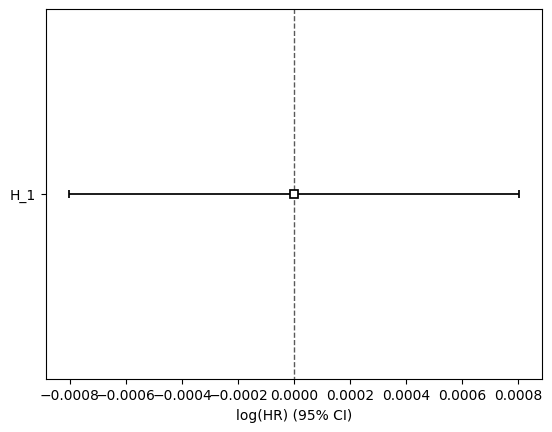

In [29]:
ctv.plot()

In [214]:
# reload all
importlib.reload(utils); importlib.reload(nwm); importlib.reload(gp_a1)
importlib.reload(utils_a1); importlib.reload(dkatlas)

<module 'desikan_killiany_atlas' from 'C:\\Users\\sranasin\\PycharmProjects\\NetworkModels\\Project1\\A3\\desikan_killiany_atlas.py'>

### DK Local props for TAU

In [216]:
params = {'ngeom_edges_in_persistence': True, 'max_persistence_dim': 2,
               'calculate_representation': True, 'bandwidth': 0.1,
               'resolution': 50, 'num_landscapes': 3,
               'representation_choice_function': 'persistence',
                'non_active': -1,
               'type_filter': 'tau'}
params['query_filter'] = "rid in [751, 1190, 2180, 2380, 4076, 4114, 4115, 4179, 4197, 4198, 4278, 4365, 4422, 4538, 4637, 4706, 4785, 4862, 4891, 5132, 5265, 5277, 6001, 6061, 6073, 6189, 6222, 6241, 6252, 6345, 6411, 6497, 6529, 6632, 6640, 6668, 6724, 6788, 6800, 6805]"
adni_data_rel_path = os.path.join("resources", "adni_pet_image_analysis", "TAU", "ADNI_merged_diagnosis.csv")
graph_file_rel_path = os.path.join("resources", "base_data", "DKATLAS33_base.graphml")

In [217]:
df_adni = utils.df_rename_to_fsnames(adni_data_rel_path, query_filter=params['query_filter'], type_filter="tau")
df_adni = utils.safe_filter_df(df_adni, True, type_filter="tau")
df_adni.sort_values(by = ['rid', 'scandate'], inplace = True)
# df_adni = df_adni.query(params.get('query_filter'))
df_adni, feature_cols = utils.activations_cortical_regions_df(df_adni, True)

In [218]:
df_adni.head(5)

,loniuid,ptid,rid,scandate,qc_flag,tracer,summary_diagnosis_MCI,summary_diaggnosis_AD,rh_lateralorbitofrontal,rh_parsorbitalis,...,lh_transversetemporal_positivity,lh_insula_positivity,lh_thalamus_proper_positivity,lh_caudate_positivity,lh_putamen_positivity,lh_pallidum_positivity,lh_accumbens_area_positivity,lh_hippocampus_positivity,lh_amygdala_positivity,brainstem_positivity
72,1596185,023_S_1190,1190,02/20/2020,1,FTP,1,1,1.163,1.157,...,0,0,0,1,1,1,1,0,1,0
71,1596176,023_S_1190,1190,02/27/2019,1,FTP,1,1,1.218,1.192,...,0,0,0,1,1,1,1,0,1,0
69,1596154,023_S_1190,1190,05/17/2016,2,FTP,1,0,1.145,1.093,...,0,0,0,1,1,1,1,0,1,0
70,1596170,023_S_1190,1190,11/08/2017,1,FTP,1,1,1.286,1.235,...,0,0,0,1,1,1,1,0,1,0
139,1614207,036_S_2380,2380,01/13/2021,2,FTP,1,1,1.783,1.480,...,0,1,1,0,1,1,1,1,1,0


In [202]:
(activation_times, snapshots, state_values) = utils.activation_times_of_patients_for_cortical_regions_df(df_adni,feature_cols,True, type_filter="tau")
print(f"Dataset proceeds with shape: {df.shape}")

(100, 179)
Dataset proceeds with shape: (130, 188)


In [119]:
pd.set_option("display.max_rows", 10)
df_adni

,loniuid,ptid,rid,scandate,qc_flag,tracer,summary_diagnosis_MCI,summary_diaggnosis_AD,rh_lateralorbitofrontal,rh_parsorbitalis,...,lh_transversetemporal_positivity,lh_insula_positivity,lh_thalamus_proper_positivity,lh_caudate_positivity,lh_putamen_positivity,lh_pallidum_positivity,lh_accumbens_area_positivity,lh_hippocampus_positivity,lh_amygdala_positivity,brainstem_positivity
69,1596154,023_S_1190,1190,05/17/2016,2,FTP,1,0,1.145,1.093,...,0,0,0,1,1,1,1,0,1,0
70,1596170,023_S_1190,1190,11/08/2017,1,FTP,1,1,1.286,1.235,...,0,0,0,1,1,1,1,0,1,0
71,1596176,023_S_1190,1190,02/27/2019,1,FTP,1,1,1.218,1.192,...,0,0,0,1,1,1,1,0,1,0
72,1596185,023_S_1190,1190,02/20/2020,1,FTP,1,1,1.163,1.157,...,0,0,0,1,1,1,1,0,1,0
138,1597779,036_S_2380,2380,06/19/2018,2,FTP,1,0,1.601,1.358,...,0,1,1,1,1,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1344,1595039,016_S_6800,6800,12/10/2019,2,FTP,1,0,1.177,1.085,...,0,0,0,0,1,1,0,1,1,0
1345,1610542,016_S_6800,6800,03/24/2021,2,FTP,1,1,1.238,1.144,...,0,0,0,0,1,1,1,1,1,0
1352,1602351,131_S_6805,6805,12/19/2019,2,FTP,1,0,1.380,1.204,...,0,0,0,0,1,1,0,0,0,0
1354,1614512,131_S_6805,6805,01/26/2022,2,FTP,1,1,1.506,1.449,...,0,0,0,0,1,1,0,1,1,0


In [203]:
df = df_adni.copy()

In [204]:
# tau suvr differneces
NODE_FSREGION_TO_ID = utils.NODE_FSREGION_TO_ID
regions = list(NODE_FSREGION_TO_ID.keys())
delta_diff = 0.1

# activation differences
# NODE_FSREGION_TO_ID = [f"{col}_positivity" for col in NODE_FSREGION_TO_ID]
# regions = NODE_FSREGION_TO_ID
# delta_diff = 0

DX_ORDER = {"CN": 0, "MCI": 1, "AD": 2}
TRANSITIONS = [("CN", "MCI"), ("MCI", "AD"), ("CN", "AD")]


In [205]:
df["scandate"] = pd.to_datetime(df["scandate"])
df["dx_rank"]  = df["PDX"].map(DX_ORDER)

# Should already be nan filtered. but whateves,
df = (
    df.dropna(subset=["dx_rank"])
    .sort_values(["rid", "scandate"])
)

In [206]:
# we only need the initial scan per patient for CN, MCI or AD, And last
patient_stage = (
    df.groupby(["rid", "PDX"])
      .last()
      .reset_index()
    )[["rid", "PDX", "dx_rank"] + regions]

In [207]:
patient_stage.head(10)

,rid,PDX,dx_rank,rh_lateralorbitofrontal,rh_parsorbitalis,rh_frontalpole,rh_medialorbitofrontal,rh_parstriangularis,rh_parsopercularis,rh_rostralmiddlefrontal,...,lh_transversetemporal,lh_insula,lh_thalamus_proper,lh_caudate,lh_putamen,lh_pallidum,lh_accumbens_area,lh_hippocampus,lh_amygdala,brainstem
0,1190,AD,2,1.163,1.157,0.993,1.042,1.060,1.066,1.028,...,1.070,1.163,1.197,1.438,1.844,1.857,1.442,1.113,1.351,0.955
1,1190,MCI,1,1.145,1.093,1.004,1.091,1.073,1.091,1.048,...,1.087,1.165,1.190,1.528,1.910,1.790,1.620,1.127,1.273,0.975
2,2380,AD,2,1.783,1.480,1.648,1.668,1.420,1.660,1.578,...,1.243,1.437,1.307,1.241,1.673,1.845,1.817,1.631,2.007,0.987
3,2380,MCI,1,1.601,1.358,1.425,1.539,1.311,1.416,1.307,...,1.127,1.345,1.334,1.294,1.690,1.937,1.791,1.699,2.130,1.024
4,4076,CN,0,1.191,1.145,0.952,1.064,1.078,1.018,1.102,...,0.971,1.074,1.290,1.190,1.613,1.569,1.347,1.365,1.234,0.956
5,4076,MCI,1,1.146,1.133,0.990,1.058,1.055,1.020,1.124,...,0.984,1.087,1.292,1.261,1.707,1.538,1.470,1.401,1.226,0.941
6,4114,AD,2,1.270,1.292,0.952,1.184,1.246,1.264,1.189,...,1.200,1.250,1.305,1.125,1.493,1.663,1.460,1.639,2.022,1.028
7,4114,MCI,1,1.292,1.429,1.028,1.131,1.350,1.274,1.203,...,1.157,1.221,1.171,1.019,1.420,1.534,1.325,1.611,2.059,0.973
8,4115,AD,2,1.126,1.160,0.949,1.001,1.042,1.021,1.032,...,0.954,1.028,1.168,0.999,1.388,1.550,1.196,1.068,1.089,0.991
9,4115,MCI,1,1.175,1.147,1.097,1.051,1.072,1.039,1.049,...,0.999,1.057,1.110,1.014,1.319,1.483,1.142,1.082,1.125,0.913


In [160]:
# Differencesss
records = []

for rid, grp in patient_stage.groupby("rid"):
    stages = grp.set_index("PDX")

    for from_dx, to_dx in TRANSITIONS:
        if from_dx in stages.index and to_dx in stages.index:
            row_from = stages.loc[from_dx, regions]
            row_to   = stages.loc[to_dx,   regions]

            delta = row_to - row_from          # signed change per region
            activated = (delta > delta_diff).astype(int)  # 1 = region increased

            records.append({
                "rid":        rid,
                "transition": f"{from_dx}→{to_dx}",
                **delta.add_prefix("delta_").to_dict(),
                **activated.add_prefix("activated_").to_dict(),
            })

transitions_df = pd.DataFrame(records)
transitions_df.head()

,rid,transition,delta_rh_lateralorbitofrontal,delta_rh_parsorbitalis,delta_rh_frontalpole,delta_rh_medialorbitofrontal,delta_rh_parstriangularis,delta_rh_parsopercularis,delta_rh_rostralmiddlefrontal,delta_rh_superiorfrontal,...,activated_lh_transversetemporal,activated_lh_insula,activated_lh_thalamus_proper,activated_lh_caudate,activated_lh_putamen,activated_lh_pallidum,activated_lh_accumbens_area,activated_lh_hippocampus,activated_lh_amygdala,activated_brainstem
0,1190,MCI→AD,0.018,0.064,-0.011,-0.049,-0.013,-0.025,-0.020,-0.007,...,0,0,0,0,0,0,0,0,0,0
1,2380,MCI→AD,0.182,0.122,0.223,0.129,0.109,0.244,0.271,0.146,...,1,0,0,0,0,0,0,0,0,0
2,4076,CN→MCI,-0.045,-0.012,0.038,-0.006,-0.023,0.002,0.022,0.011,...,0,0,0,0,0,0,1,0,0,0
3,4114,MCI→AD,-0.022,-0.137,-0.076,0.053,-0.104,-0.010,-0.014,0.041,...,0,0,1,1,0,1,1,0,0,0
4,4115,MCI→AD,-0.049,0.013,-0.148,-0.050,-0.030,-0.018,-0.017,-0.011,...,0,0,0,0,0,0,0,0,0,0


In [162]:
# how often these regions activate?
# TODO: how to build a confidence for each Diagnosis level
summary_rows = []

for transition, grp in transitions_df.groupby("transition"):
    n = len(grp)
    act_cols = [f"activated_{r}" for r in regions]

    activation_rate = grp[act_cols].mean()   # proportion of patients where region increased
    mean_delta      = grp[[f"delta_{r}" for r in regions]].mean()

    row = {"transition": transition, "n_patients": n}
    for r in regions:
        row[f"act_rate_{r}"]  = activation_rate[f"activated_{r}"]
        row[f"mean_delta_{r}"] = mean_delta[f"delta_{r}"]
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("transition")

summary_df.T

transition,CN→MCI,MCI→AD
n_patients,13.000000,23.000000
act_rate_rh_lateralorbitofrontal,0.307692,0.217391
mean_delta_rh_lateralorbitofrontal,0.040615,0.045957
act_rate_rh_parsorbitalis,0.230769,0.260870
mean_delta_rh_parsorbitalis,0.029615,0.042000
...,...,...
mean_delta_lh_hippocampus,0.028308,-0.017783
act_rate_lh_amygdala,0.461538,0.347826
mean_delta_lh_amygdala,0.084308,0.004130
act_rate_brainstem,0.076923,0.000000


In [164]:
# Top activated regions per transition
# TODO:
for transition, row in summary_df.iterrows():
    act_rates = {
        r: row[f"act_rate_{r}"] for r in regions
    }
    top = sorted(act_rates, key=act_rates.get, reverse=True)[:20]
    print(f"{transition}  (n={int(row['n_patients'])})")
    for r in top:
        print(f"  {r:<40s}  activation rate: {act_rates[r]:.1%}")
    print()

CN→MCI  (n=13)
  rh_fusiform                               activation rate: 46.2%
  rh_bankssts                               activation rate: 46.2%
  rh_putamen                                activation rate: 46.2%
  lh_lateraloccipital                       activation rate: 46.2%
  lh_bankssts                               activation rate: 46.2%
  lh_accumbens_area                         activation rate: 46.2%
  lh_amygdala                               activation rate: 46.2%
  rh_isthmuscingulate                       activation rate: 38.5%
  rh_inferiorparietal                       activation rate: 38.5%
  rh_entorhinal                             activation rate: 38.5%
  rh_middletemporal                         activation rate: 38.5%
  rh_accumbens_area                         activation rate: 38.5%
  rh_amygdala                               activation rate: 38.5%
  lh_inferiorparietal                       activation rate: 38.5%
  lh_putamen                                act

### DK Local props AMyloid

In [189]:
params['query_filter'] = "rid in [751, 1190, 2180, 2380, 4076, 4114, 4115, 4179, 4197, 4198, 4278, 4365, 4422, 4538, 4637, 4706, 4785, 4862, 4891, 5132, 5265, 5277, 6001, 6061, 6073, 6189, 6222, 6241, 6252, 6345, 6411, 6497, 6529, 6632, 6640, 6668, 6724, 6788, 6800, 6805]"

In [192]:
adni_data_rel_path = os.path.join("resources", "TEST_NEW", "structured_files_UCBERKELEY_AMY_6MM_29Oct2025", "UCBERKELEY_AMY_6MM_29Oct2025_suvr.csv")
graph_file_rel_path = os.path.join("resources", "base_data", "DKATLAS33_base.graphml")
df_adni = utils.df_rename_to_fsnames(adni_data_rel_path, query_filter=params['query_filter'], type_filter="amyloid")
df_adni = utils.safe_filter_df(df_adni, True, type_filter="amyloid")
df_adni.sort_values(by=['rid', 'scandate'], inplace=True)
df_adni = df_adni.query(params.get('query_filter'))
df_adni, feature_cols = utils.activations_cortical_regions_df(df_adni, True)
df_adni['scandate'] = pd.to_datetime(df_adni['scandate'])

In [193]:
df_tau_pdx = df[['rid', 'scandate', 'PDX']]
df_adni = df_adni.merge(df_tau_pdx, left_on = ['rid', 'scandate'], right_on = ['rid', 'scandate'], how = 'left')
df_adni.head()

,loniuid,ptid,rid,scandate,qc_flag,tracer,amyloid_status,amyloid_status_composite_ref,centiloids,summary_suvr,...,lh_insula_positivity,lh_thalamus_proper_positivity,lh_caudate_positivity,lh_putamen_positivity,lh_pallidum_positivity,lh_accumbens_area_positivity,lh_hippocampus_positivity,lh_amygdala_positivity,brainstem_positivity,PDX
0,1596153,023_S_1190,1190,2011-03-29,2,FBP,1.0,1.0,51.0,1.276,...,1,1,0,1,1,1,0,0,1,NaN
1,1596214,023_S_1190,1190,2014-02-19,2,FBP,1.0,1.0,37.0,1.203,...,1,1,0,1,1,1,0,0,1,NaN
2,1596168,023_S_1190,1190,2017-10-25,2,FBP,1.0,1.0,36.0,1.196,...,1,0,0,1,1,0,0,0,1,NaN
3,1596235,023_S_1190,1190,2019-10-23,1,FBP,1.0,1.0,80.0,1.430,...,1,1,1,1,1,1,0,1,1,NaN
4,1610563,018_S_2180,2180,2022-02-14,2,FBP,0.0,0.0,2.0,1.016,...,0,1,0,1,1,0,0,0,1,NaN


In [194]:
df = df_adni.copy()

In [195]:
df["scandate"] = pd.to_datetime(df["scandate"])
df["dx_rank"]  = df["PDX"].map(DX_ORDER)

# Should already be nan filtered. but whateves,
# df = (
#     df.dropna(subset=["dx_rank"])
#     .sort_values(["rid", "scandate"])
# )

In [196]:
patient_stage = (
    df.groupby(["rid", "PDX"])
      .last()
      .reset_index()
    )[["rid", "PDX", "dx_rank"] + regions]

In [197]:
df

,loniuid,ptid,rid,scandate,qc_flag,tracer,amyloid_status,amyloid_status_composite_ref,centiloids,summary_suvr,...,lh_thalamus_proper_positivity,lh_caudate_positivity,lh_putamen_positivity,lh_pallidum_positivity,lh_accumbens_area_positivity,lh_hippocampus_positivity,lh_amygdala_positivity,brainstem_positivity,PDX,dx_rank
0,1596153,023_S_1190,1190,2011-03-29,2,FBP,1.0,1.0,51.0,1.276,...,1,0,1,1,1,0,0,1,NaN,NaN
1,1596214,023_S_1190,1190,2014-02-19,2,FBP,1.0,1.0,37.0,1.203,...,1,0,1,1,1,0,0,1,NaN,NaN
2,1596168,023_S_1190,1190,2017-10-25,2,FBP,1.0,1.0,36.0,1.196,...,0,0,1,1,0,0,0,1,NaN,NaN
3,1596235,023_S_1190,1190,2019-10-23,1,FBP,1.0,1.0,80.0,1.430,...,1,1,1,1,1,0,1,1,NaN,NaN
4,1610563,018_S_2180,2180,2022-02-14,2,FBP,0.0,0.0,2.0,1.016,...,1,0,1,1,0,0,0,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,1613266,027_S_6788,6788,2021-11-30,2,FBB,1.0,1.0,100.0,1.602,...,1,1,1,1,1,1,1,1,NaN,NaN
126,11039457,027_S_6788,6788,2024-10-23,2,FBB,1.0,1.0,57.0,1.328,...,1,0,1,1,1,0,1,1,NaN,NaN
127,1595091,016_S_6800,6800,2019-10-22,2,FBB,1.0,1.0,118.0,1.716,...,1,1,1,1,1,1,1,1,NaN,NaN
128,1602265,131_S_6805,6805,2020-01-09,2,FBB,1.0,1.0,90.0,1.536,...,0,0,1,1,1,0,0,1,NaN,NaN


In [198]:
# Differencesss
records = []

for rid, grp in patient_stage.groupby("rid"):
    stages = grp.set_index("PDX")

    for from_dx, to_dx in TRANSITIONS:
        if from_dx in stages.index and to_dx in stages.index:
            row_from = stages.loc[from_dx, regions]
            row_to   = stages.loc[to_dx,   regions]

            delta = row_to - row_from          # signed change per region
            activated = (delta > delta_diff).astype(int)  # 1 = region increased

            records.append({
                "rid":        rid,
                "transition": f"{from_dx}→{to_dx}",
                **delta.add_prefix("delta_").to_dict(),
                **activated.add_prefix("activated_").to_dict(),
            })

transitions_df = pd.DataFrame(records)
transitions_df.head()

""


In [ ]:
# how often these regions activate?
# TODO: how to build a confidence for each Diagnosis level
summary_rows = []

for transition, grp in transitions_df.groupby("transition"):
    n = len(grp)
    act_cols = [f"activated_{r}" for r in regions]

    activation_rate = grp[act_cols].mean()   # proportion of patients where region increased
    mean_delta      = grp[[f"delta_{r}" for r in regions]].mean()

    row = {"transition": transition, "n_patients": n}
    for r in regions:
        row[f"act_rate_{r}"]  = activation_rate[f"activated_{r}"]
        row[f"mean_delta_{r}"] = mean_delta[f"delta_{r}"]
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("transition")

summary_df.T

In [ ]:
# Top activated regions per transition
# TODO:
for transition, row in summary_df.iterrows():
    act_rates = {
        r: row[f"act_rate_{r}"] for r in regions
    }
    top = sorted(act_rates, key=act_rates.get, reverse=True)[:20]
    print(f"{transition}  (n={int(row['n_patients'])})")
    for r in top:
        print(f"  {r:<40s}  activation rate: {act_rates[r]:.1%}")
    print()

### Braak scores from: [ADNI_UCBerkeley](https://adni.bitbucket.io/reference/docs/UCBERKELEYAV1451/UCBERKELEY_AV1451_Methods_Aug2018.pdf)

In [ ]:
braak_scores = {
    # Braak 1
'rh_entorhinal':               1,
'lh_entorhinal':               1,

# Braak 2
'rh_hippocampus':              2,
'lh_hippocampus':              2,

# Braak 3
'rh_parahippocampal':          3,
'lh_parahippocampal':          3,
'rh_fusiform':                 3,
    'lh_fusiform':                 3,
    'rh_lingual':                  3,
'lh_lingual':                  3,
'rh_amygdala':                 3,
'lh_amygdala':                 3,

# Braak 4
'rh_middletemporal':           4,
'lh_middletemporal':           4,
'rh_caudalanteriorcingulate':  4,
'lh_caudalanteriorcingulate':  4,
'rh_rostralanteriorcingulate': 4,
'lh_rostralanteriorcingulate': 4,
'rh_posteriorcingulate':       4,
'lh_posteriorcingulate':       4,
'rh_isthmuscingulate':         4,
'lh_isthmuscingulate':         4,
'rh_insula':                   4,
'lh_insula':                   4,
'rh_inferiortemporal':         4,
'lh_inferiortemporal':         4,
'rh_temporalpole':             4,
'lh_temporalpole':             4,

# Braak 5
'rh_superiorfrontal':          5,
'lh_superiorfrontal':          5,
'rh_lateralorbitofrontal':     5,
'lh_lateralorbitofrontal':     5,
'rh_medialorbitofrontal':      5,
'lh_medialorbitofrontal':      5,
'rh_frontalpole':              5,
'lh_frontalpole':              5,
'rh_caudalmiddlefrontal':      5,
'lh_caudalmiddlefrontal':      5,
'rh_rostralmiddlefrontal':     5,
'lh_rostralmiddlefrontal':     5,
'rh_parsopercularis':          5,
'lh_parsopercularis':          5,
'rh_parsorbitalis':            5,
'lh_parsorbitalis':            5,
'rh_parstriangularis':         5,
'lh_parstriangularis':         5,
'rh_lateraloccipital':         5,
'lh_lateraloccipital':         5,
'rh_supramarginal':            5,
'lh_supramarginal':            5,
'rh_inferiorparietal':         5,
'lh_inferiorparietal':         5,
'rh_superiortemporal':         5,
'lh_superiortemporal':         5,
'rh_superiorparietal':         5,
'lh_superiorparietal':         5,
'rh_precuneus':                5,
'lh_precuneus':                5,
'rh_bankssts':                 5,
'lh_bankssts':                 5,
'rh_transversetemporal':       5,
'lh_transversetemporal':       5,
#BRaak 6
'rh_pericalcarine':            6,
'lh_pericalcarine':            6,
'rh_postcentral':              6,
'lh_postcentral':              6,
'rh_cuneus':                   6,
'lh_cuneus':                   6,
'rh_precentral':               6,
'lh_precentral':               6,
'rh_paracentral':              6,
'lh_paracentral':              6,

#################
# Not in ADNI packet
'rh_thalamus_proper':          0,
'lh_thalamus_proper':          0,
'rh_caudate':                  0,
'lh_caudate':                  0,
'rh_putamen':                  0,
'lh_putamen':                  0,
'rh_pallidum':                 0,
'lh_pallidum':                 0,
'rh_accumbens_area':           0,
'lh_accumbens_area':           0,
'brainstem':                   0,
}